# **Neural Models - Hands-On**

## **Task 1: Understand the problem before coding**



### **Problem Specification**

**Input space:** X = {0,1}²
**Output space:** Y = {0,1}

| x1 | x2 | y |
|----|----|---|
| 0  | 0  | 0 |
| 0  | 1  | 1 |
| 1  | 0  | 1 |
| 1  | 1  | 0 |

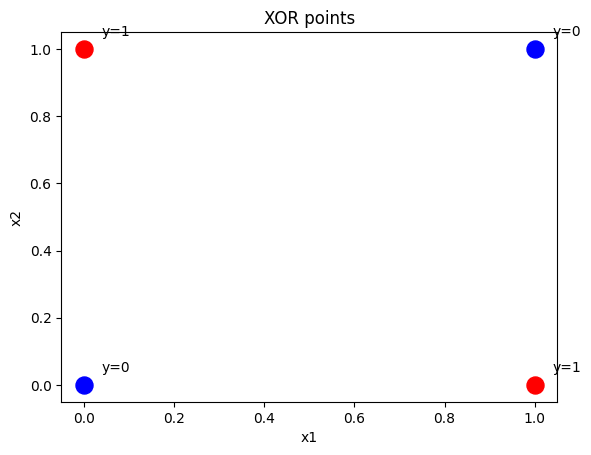

In [2]:
import matplotlib.pyplot as plt
points = [(0,0,0), (0,1,1), (1,0,1), (1,1,0)]
for x1, x2, y in points:
    plt.scatter(x1, x2, c="red" if y else "blue", s=150)
    plt.annotate(f"y={y}", (x1+0.04, x2+0.04))
plt.xlabel("x1"); plt.ylabel("x2"); plt.title("XOR points"); plt.show()

### **Why No Straight Line Works**

A linear classifier predicts 1 when w1*x1 + w2*x2 + b > 0. The four examples require:
b <= 0 (for 00), w2 + b > 0 (for 01), w1 + b > 0 (for 10), w1 + w2 + b <= 0 (for 11).
Adding the middle two gives w1 + w2 + 2b > 0, so w1 + w2 + b > -b >= 0,
which contradicts the last condition. Geometrically, the class-1 points lie on one
diagonal of the square and the class-0 points on the other, so no single line
separates them.

### **Prediction**

A single affine layer + sigmoid cannot learn XOR. The best it can do is
output about 0.5 for every input, giving a loss near ln 2 = 0.693 and at most 3 of the
4 examples correct.

**Think About It:** XOR lets us test whether representation, not parameter count, is what matters. A model whose features are affine in the input cannot represent XOR, however many parameters it has.

## **Task 2: Design the intelligent agent**

### **Model Specification**

- Architecture: 2 inputs -> 2 hidden units (tanh) -> 1 output logit -> sigmoid.
- Loss: binary cross-entropy (BCEWithLogitsLoss, which combines sigmoid + BCE stably).
- Optimiser: full-batch Adam, learning rate 0.05, 3000 steps.

### **Answers**

1. Why a hidden nonlinearity: without it, W2(W1 x + b1) + b2 collapses into a single
   affine map, so the network is still linear and cannot represent XOR. The nonlinearity
   lets the two hidden units compute different features that the output can combine.

2. Why sigmoid + BCE: the target is one yes/no answer, so the sigmoid output is a
   probability, and BCE is its negative log-likelihood. The gradient with respect to the
   logit is simply p - y, so a confident wrong answer still gets a large gradient.

3. Evidence of successful learning:
   (a) final loss well below 0.693 (e.g. < 0.05) and decreasing over training;
   (b) all four thresholded predictions correct, with probabilities < 0.1 or > 0.9;
   (c) first-layer gradient nonzero at the start and shrinking toward zero at the end;
   (d) it works across many random seeds, not just one.

**Think About It:** The hidden units are never given targets. Backpropagation sends the output error backwards through the chain rule, δ_hidden = (W₂ᵀ δ_out) ⊙ f′(a), so each hidden unit's role is shaped by how it can help reduce the final loss.

## **Task 3: Use an LLM to generate a first implementation**

### **Prompt:**

Generate minimal PyTorch code for the following model and dataset. Do not change the architecture or task.

Data (full batch): (0,0)->0, (0,1)->1, (1,0)->1, (1,1)->0.
Model: 2-2-1 network, tanh hidden activation, one output logit used with BCEWithLogitsLoss
(sigmoid + binary cross-entropy), random weight initialisation.
Training: Adam, lr 0.05, 3000 full-batch steps, CPU.
After training, report the final loss, all four probabilities, thresholded labels, and the
gradient of the first-layer weights after backward().
Set a random seed for reproducibility and explain each test in one sentence.

In [3]:
import torch
import torch.nn as nn

torch.set_default_dtype(torch.float64)
SEED = 0
torch.manual_seed(SEED)

X = torch.tensor([[0.,0.],[0.,1.],[1.,0.],[1.,1.]])
Y = torch.tensor([[0.],[1.],[1.],[0.]])

model = nn.Sequential(nn.Linear(2, 2), nn.Tanh(), nn.Linear(2, 1))  # 2-2-1, outputs a logit
loss_fn = nn.BCEWithLogitsLoss()
opt = torch.optim.Adam(model.parameters(), lr=0.05)

for step in range(3000):
    opt.zero_grad()
    loss = loss_fn(model(X), Y)   # forward pass + scalar loss
    loss.backward()               # reverse-mode AD
    opt.step()                    # optimiser updates parameters

with torch.no_grad():
    logits = model(X)
    probs = torch.sigmoid(logits).squeeze(1)
    preds = (probs > 0.5).double()
    final_loss = loss_fn(logits, Y).item()

print("final loss:", final_loss)
print("probabilities:", probs.tolist())
print("labels:", preds.tolist(), "targets:", Y.squeeze(1).tolist())

# gradient tensor after one more backward()
model.zero_grad()
loss_fn(model(X), Y).backward()
print("grad of first-layer weights:\n", model[0].weight.grad)

final loss: 0.00010820018389235566
probabilities: [7.729241406516965e-05, 0.9998363306788756, 0.9998794232227065, 7.123603321801438e-05]
labels: [0.0, 1.0, 1.0, 0.0] targets: [0.0, 1.0, 1.0, 0.0]
grad of first-layer weights:
 tensor([[-3.8128e-06,  4.4749e-06],
        [ 4.4323e-06, -2.4206e-06]])


### **Inspection of Code:**

- Forward pass: `model(X)`, which computes the logits for all four examples.
- Scalar loss: `loss = loss_fn(model(X), Y)`, the mean BCE over the four examples.
- Reverse-mode AD: `loss.backward()`, which fills `p.grad` with dL/dp for every parameter.
- Parameter update: `opt.step()`, where Adam modifies the weights using those gradients.
- `opt.zero_grad()` at the start of each step clears old gradients so they don't accumulate.

**No changes made**

### **Results:**

Final loss: 1.08e-4
- Probabilities: [7.7e-05, 0.99984, 0.99988, 7.1e-05]
- Thresholded labels: [0, 1, 1, 0]
- Gradient of first-layer weights (2x2): entries of order 1e-6, i.e. close to zero,
as expected after convergence.



**Think About It:**
- Verifiable by reading the code without running it: the architecture is 2-2-1, the output and
loss pairing is correct (logits with BCEWithLogitsLoss), the training data match the task,
and zero_grad/backward/step are in the correct order.

- Requires execution and measurement: whether training actually converges, the final loss and
probabilities, the size of the gradients, and whether it works across different seeds.
An LLM can write syntactically valid code that runs but implements the wrong experiment,
so the numbers have to be checked.

## **Task 4: Execute, test, and diagnose the generated code**

In [2]:
import torch, torch.nn as nn
torch.set_default_dtype(torch.float64)

X = torch.tensor([[0.,0.],[0.,1.],[1.,0.],[1.,1.]])
Y = torch.tensor([[0.],[1.],[1.],[0.]])
bce = nn.BCEWithLogitsLoss()
ACTS = {"sigmoid": nn.Sigmoid, "tanh": nn.Tanh, "relu": nn.ReLU}

def make_model(act="tanh", seed=0, zero_init=False):
    torch.manual_seed(seed)
    m = nn.Sequential(nn.Linear(2,2), ACTS[act](), nn.Linear(2,1))
    if zero_init:
        for p in m.parameters():
            nn.init.zeros_(p)
    return m

def evaluate(m):
    with torch.no_grad():
        logits = m(X); p = torch.sigmoid(logits)
        pred = (p > 0.5).double()
        return bce(logits, Y).item(), p.squeeze(1), pred.squeeze(1), bool((pred == Y).all())

def train(m, steps=3000, lr=0.05, hook=None):
    opt = torch.optim.Adam(m.parameters(), lr=lr)
    init_loss = bce(m(X), Y).item()
    early = None
    for t in range(steps):
        opt.zero_grad()
        loss = bce(m(X), Y)
        loss.backward()
        if t == 0:
            early = m[0].weight.grad.norm().item()
        if hook: hook(t, m)
        opt.step()
    return init_loss, early

In [5]:
m = make_model("tanh", 0)
init_loss, early = train(m)
loss, p, pred, ok = evaluate(m)
print("initial loss:", init_loss, "| final loss:", loss)
print("probabilities:", p.tolist())
print("labels:", pred.tolist(), "| all correct:", ok)

initial loss: 0.7101756328527842 | final loss: 0.00010820018389235566
probabilities: [7.729241406516965e-05, 0.9998363306788756, 0.9998794232227065, 7.123603321801438e-05]
labels: [0.0, 1.0, 1.0, 0.0] | all correct: True


**Part A:**

- Initial loss: 0.7101756328527842
- Final loss: 0.00010820018389235566
- Probabilities: [7.729241406516965e-05, 0.9998363306788756, 0.9998794232227065, 7.123603321801438e-05]
- Thresholded labels: [0, 1, 1, 0]. All four are correct.

In [3]:
m = make_model("tanh", 0); train(m)
m.zero_grad()
bce(m(X), Y).backward()
g_batch = m[0].weight.grad.clone()
print("dL/dW1 from .grad:\n", g_batch)

per_ex = [torch.autograd.grad(bce(m(X[i:i+1]), Y[i:i+1]), m[0].weight)[0] for i in range(4)]
g_avg = torch.stack(per_ex).mean(0)
print("average of per-example gradients:\n", g_avg)
print("equal?", torch.allclose(g_batch, g_avg))

eps, w = 1e-6, m[0].weight
orig = w.data[0,0].item()
w.data[0,0] = orig + eps; lp = bce(m(X), Y).item()
w.data[0,0] = orig - eps; lm = bce(m(X), Y).item()
w.data[0,0] = orig
print("finite difference:", (lp - lm)/(2*eps), "| autograd:", g_batch[0,0].item())

dL/dW1 from .grad:
 tensor([[-3.8128e-06,  4.4749e-06],
        [ 4.4323e-06, -2.4206e-06]])
average of per-example gradients:
 tensor([[-3.8128e-06,  4.4749e-06],
        [ 4.4323e-06, -2.4206e-06]])
equal? True
finite difference: -3.8126932776845653e-06 | autograd: -3.8128200292008153e-06


**Part B:**

parameter.grad for the first-layer weight stores dL/dW(1), a 2x2 matrix. Entry (j,k) tells how much the loss changes per unit change of the weight from input k to hidden unit j.

The loss is the mean over the four examples, L = (1/4) * sum(L_i). Differentiation is linear,
so dL/dW = (1/4) * sum(dL_i/dW). The gradient of the mean loss is therefore the average of the
example-wise gradients. Checked numerically, the average of the four per-example gradients
equals .grad (allclose = True), and a central finite-difference estimate (-3.8126932776845653e-06) matches
autograd (-3.8128200292008153e-06).

In [4]:
for act in ["sigmoid", "tanh"]:
    print(f"\n--- {act}, all weights and biases = 0 ---")
    def hook(t, mm):
        if t in (0, 1, 10, 100, 1000, 2999):
            W = mm[0].weight
            d = (W.data[0] - W.data[1]).abs().max().item()
            print(f"step {t:4d} row0={[round(v,5) for v in W.data[0].tolist()]} "
                  f"row1={[round(v,5) for v in W.data[1].tolist()]} max|diff|={d:.1e} "
                  f"|grad|={W.grad.norm().item():.1e}")
    mz = make_model(act, 0, zero_init=True)
    train(mz, hook=hook)
    l, p, pred, ok = evaluate(mz)
    print("final loss:", round(l, 4), "| probs:", [round(v,4) for v in p.tolist()], "| all correct:", ok)


--- sigmoid, all weights and biases = 0 ---
step    0 row0=[0.0, 0.0] row1=[0.0, 0.0] max|diff|=0.0e+00 |grad|=0.0e+00
step    1 row0=[0.0, 0.0] row1=[0.0, 0.0] max|diff|=0.0e+00 |grad|=0.0e+00
step   10 row0=[0.0, 0.0] row1=[0.0, 0.0] max|diff|=0.0e+00 |grad|=0.0e+00
step  100 row0=[0.0, 0.0] row1=[0.0, 0.0] max|diff|=0.0e+00 |grad|=0.0e+00
step 1000 row0=[0.0, 0.0] row1=[0.0, 0.0] max|diff|=0.0e+00 |grad|=0.0e+00
step 2999 row0=[0.0, 0.0] row1=[0.0, 0.0] max|diff|=0.0e+00 |grad|=0.0e+00
final loss: 0.6931 | probs: [0.5, 0.5, 0.5, 0.5] | all correct: False

--- tanh, all weights and biases = 0 ---
step    0 row0=[0.0, 0.0] row1=[0.0, 0.0] max|diff|=0.0e+00 |grad|=0.0e+00
step    1 row0=[0.0, 0.0] row1=[0.0, 0.0] max|diff|=0.0e+00 |grad|=0.0e+00
step   10 row0=[0.0, 0.0] row1=[0.0, 0.0] max|diff|=0.0e+00 |grad|=0.0e+00
step  100 row0=[0.0, 0.0] row1=[0.0, 0.0] max|diff|=0.0e+00 |grad|=0.0e+00
step 1000 row0=[0.0, 0.0] row1=[0.0, 0.0] max|diff|=0.0e+00 |grad|=0.0e+00
step 2999 row0=[0.

In [5]:
mc = make_model("tanh", 0)
for p in mc.parameters():
    nn.init.constant_(p, 0.5)
def hook(t, mm):
    if t in (0, 10, 100, 1000, 2999):
        W = mm[0].weight
        print(f"step {t:4d} row0={[round(v,4) for v in W.data[0].tolist()]} "
              f"row1={[round(v,4) for v in W.data[1].tolist()]} max|diff|={(W.data[0]-W.data[1]).abs().max().item():.1e}")
train(mc, hook=hook)
l, p, pred, ok = evaluate(mc)
print("final loss:", l, "| probs:", p.tolist(), "| all correct:", ok)

step    0 row0=[0.5, 0.5] row1=[0.5, 0.5] max|diff|=0.0e+00
step   10 row0=[0.0205, 0.0205] row1=[0.0205, 0.0205] max|diff|=0.0e+00
step  100 row0=[-3.9355, -3.9355] row1=[-3.9355, -3.9355] max|diff|=0.0e+00
step 1000 row0=[-6.4863, -6.4863] row1=[-6.4863, -6.4863] max|diff|=0.0e+00
step 2999 row0=[-7.7726, -7.7726] row1=[-7.7726, -7.7726] max|diff|=0.0e+00
final loss: 0.47741444343152106 | probs: [8.532150053695146e-05, 0.6666761796155043, 0.6666761796155043, 0.6666861602112871] | all correct: False


**Part C:**

- Setup:
I copied the experiment and set all weights and biases to zero, keeping the 2-2-1
architecture and the same training settings (full-batch Adam, lr 0.05, 3000 steps). I ran it with
sigmoid and with tanh hidden units and logged the two rows of the first-layer weight matrix W1 at
steps 0, 1, 10, 100, 1000 and 2999.

- Observation: For both sigmoid and tanh, the two rows of W1 remained identical at every logged
step (max|row0 - row1| = 0.0). In fact, all weights stayed exactly 0 and |grad W1| was exactly 0
throughout. The final loss was 0.6931 (= ln 2) with all four probabilities equal to 0.5, so the
network did not classify all four examples correctly.

- Explanation: Identical hidden units compute identical outputs, and the two output weights are
also equal, so both hidden units receive the same gradient and the same update at every step. Equal
rows are mapped to equal rows, so the symmetry can never be broken and the two units cannot learn
distinct features. The network effectively behaves like a single hidden unit, which cannot
represent XOR.

In this exact zero-initialised case the situation is even more degenerate. Because W2 = 0, the
gradient of W1 is exactly zero. The gradients of W2 and b2 depend on the average of (p - y), and
with sigmoid output p = 0.5 for all inputs this average is exactly zero, because XOR has two
examples of each class. So every gradient vanishes and the network never leaves its starting point.

- Control experiment: To separate the symmetry effect from the zero-gradient effect, I initialised
every parameter to the same nonzero constant (0.5). The gradient was now nonzero and the weights
moved (W1 entries went from 0.5 to about -7.77), but the two rows of W1 stayed identical at every
logged step (max|row0 - row1| = 0.0). The network ended at loss 0.477 with probabilities
approximately [0.0001, 0.667, 0.667, 0.667], i.e. only 3 of 4 examples correct (the (1,1) input
is misclassified).

- Conclusion: Identical initialisation prevents the two hidden units from learning distinct
features. They remain copies of one unit, so the network cannot represent XOR, even when the
gradients are nonzero and the loss decreases. Random initialisation breaks the symmetry, which is
why the randomly initialised network in Part A reached a loss of about 1e-4 with all four examples
correct.

In [6]:
print(f"{'activation':10s} {'final loss':>12s} {'4/4?':>6s} {'early ||grad W1||':>18s}")
trained = {}
for act in ACTS:
    ma = make_model(act, 0)
    _, early = train(ma)
    l, p, pred, ok = evaluate(ma)
    trained[act] = ma
    print(f"{act:10s} {l:12.6f} {str(ok):>6s} {early:18.6f}")

for act, mm in trained.items():
    with torch.no_grad():
        a = mm[0](X); h = mm[1](a)
    d = h*(1-h) if act=="sigmoid" else (1-h**2 if act=="tanh" else (a>0).double())
    print(f"\n{act}: pre-activations a =\n{a}\nf'(a) =\n{d}")

activation   final loss   4/4?  early ||grad W1||
sigmoid        0.000284   True           0.009625
tanh           0.000108   True           0.043654
relu           0.693147  False           0.041242

sigmoid: pre-activations a =
tensor([[ -5.1639,   5.5514],
        [  4.8481,  16.8842],
        [-15.2744,  -5.1876],
        [ -5.2624,   6.1451]])
f'(a) =
tensor([[5.6543e-03, 3.8521e-03],
        [7.7217e-03, 4.6482e-08],
        [2.3249e-07, 5.5233e-03],
        [5.1296e-03, 2.1347e-03]])

tanh: pre-activations a =
tensor([[ 2.4725,  2.4993],
        [-2.5995,  7.8584],
        [ 7.6435, -2.5497],
        [ 2.5715,  2.8093]])
f'(a) =
tensor([[2.8074e-02, 2.6627e-02],
        [2.1845e-02, 5.9749e-07],
        [9.1830e-07, 2.4105e-02],
        [2.3091e-02, 1.4413e-02]])

relu: pre-activations a =
tensor([[0.1279, 0.2762],
        [0.1211, 0.3910],
        [0.3252, 0.0487],
        [0.3184, 0.1635]])
f'(a) =
tensor([[1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.]])


In [7]:
for act in ACTS:
    wins = 0
    for s in range(20):
        mm = make_model(act, s); train(mm)
        wins += evaluate(mm)[3]
    print(act, f"{wins}/20 seeds reach 4/4")

sigmoid 7/20 seeds reach 4/4
tanh 10/20 seeds reach 4/4
relu 6/20 seeds reach 4/4


**Part D:**

Results:

| Hidden activation | Final loss | 4/4 correct? | Early ‖∇W⁽¹⁾L‖₂|
|---|---|---|---|
| Sigmoid | 0.000284 | True  | 0.009625 |
| Tanh    | 0.000108 | True  | 0.043654 |
| ReLU    | 0.693147 | False | 0.041242 |

Interpretation:

These results are for one 2-2-1 network on four points with seed 0, so we can not claim that any
activation is universally best.

- Sigmoid and tanh both classified all four examples correctly, with final losses of 2.8e-4 and
1.1e-4. ReLU failed: its final loss was 0.693147 (= ln 2, the loss of a constant 0.5 output) and
not all examples were correct.

- Early gradient: the first-layer gradient norm at step 0 was smallest for sigmoid (0.0096) and about
4.5 times larger for tanh (0.0437) and ReLU (0.0412). This is consistent with the sigmoid
derivative being at most 0.25, which scales down the backpropagated signal, while tanh has maximum
derivative 1 and an active ReLU has derivative exactly 1.

- Why ReLU failed (from the printed diagnostics): in the trained ReLU network all pre-activations
are positive, so every hidden unit is active for all four inputs and f'(a) = 1 everywhere. With no
unit ever switching off, the ReLU hidden layer behaves as a purely affine map, so the whole network
is affine and cannot represent XOR. This is not a dead-unit failure: the units are active, not
inactive. The ReLU run also shows that a nonzero gradient (0.041, similar to tanh) does not by
itself mean the network learns a useful representation.

- Sigmoid and tanh instead ended in a saturated regime: the pre-activations are large in magnitude
(up to about 17 for sigmoid, 8 for tanh) and f'(a) is very small, but not zero. These units still
act as nonlinear switches, which is what XOR needs.

- Repeated runs (20 seeds each, same settings): sigmoid reached 4/4 on 7/20 seeds, tanh on 10/20,
and ReLU on 6/20.

A 2-2-1 network trained with these settings often
fails on XOR whatever the activation: more than half of the seeds got stuck for every
activation, so the seed matters as much as the activation choice.

tanh succeeded most
often, but with only 20 seeds per activation the gaps between 10, 7 and 6 are small. Seed 0 happened to be a good seed for sigmoid and tanh and a
bad one for ReLU, which is why the single-run table makes ReLU look much worse than the sweep does.

**Think About It:**

I would inspect the pre-activations a and the derivative f'(a).
- Saturated sigmoid/tanh: |a| is large, the activation is near 0/1 (or ±1), and f'(a) is tiny but
  not exactly zero. In my run the sigmoid units had |a| up to about 17 and f'(a) between 1e-3 and
  5e-8.
- Dead ReLU: a <= 0 for every example, the activation is exactly 0, f'(a) is exactly 0, and the
  unit's gradient row is exactly zero.

The two mechanisms are told apart by the sign and size of a. My failed ReLU run was neither: the
pre-activations were all positive and f'(a) = 1, so the network was active everywhere and
therefore effectively linear.

## **Task 5: Extend the task and reflect on the outcome**

### **Prompt:**

Here is my working PyTorch code for a binary XOR network (2-2-1, tanh hidden layer, BCEWithLogitsLoss):

import torch
import torch.nn as nn

torch.set_default_dtype(torch.float64)
torch.manual_seed(0)

X = torch.tensor([[0.,0.],[0.,1.],[1.,0.],[1.,1.]])
Y = torch.tensor([[0.],[1.],[1.],[0.]])

model = nn.Sequential(nn.Linear(2, 2), nn.Tanh(), nn.Linear(2, 1))
loss_fn = nn.BCEWithLogitsLoss()
opt = torch.optim.Adam(model.parameters(), lr=0.05)

for step in range(3000):
    opt.zero_grad()
    loss = loss_fn(model(X), Y)
    loss.backward()
    opt.step()

Modify ONLY the output layer and the loss to turn this into a three-class problem. Do not change
anything else (same inputs, tanh hidden activation, Adam, lr 0.05, 3000 full-batch steps, float64).

Classes: class 0 = (0,0), class 1 = (0,1) and (1,0), class 2 = (1,1). So the class targets
for the four inputs are [0, 1, 1, 2].

Requirements:
- Use 3 hidden tanh units (keep the hidden layer small).
- Replace the single output with three logits.
- Use multiclass cross-entropy: nn.CrossEntropyLoss on integer class indices (raw logits, no
  softmax layer inside the model).
- After training, print: the shape of the final weight

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.set_default_dtype(torch.float64)

X = torch.tensor([[0.,0.],[0.,1.],[1.,0.],[1.,1.]])
T = torch.tensor([0, 1, 1, 2])              # class indices: (0,0)->0, disagree->1, (1,1)->2

def build(seed):
    torch.manual_seed(seed)
    # CHANGED: 3 hidden tanh units and 3 output logits (no softmax layer inside the model)
    return nn.Sequential(nn.Linear(2, 3), nn.Tanh(), nn.Linear(3, 3))

loss_fn = nn.CrossEntropyLoss()             # CHANGED: softmax + cross-entropy on raw logits

def train(model):
    opt = torch.optim.Adam(model.parameters(), lr=0.05)
    for step in range(3000):
        opt.zero_grad()
        loss = loss_fn(model(X), T)
        loss.backward()
        opt.step()

# Seed 0 first; if it does not classify all four correctly, try the next seeds
for seed in range(20):
    model = build(seed)
    train(model)
    if (model(X).argmax(1) == T).all():
        break
print("seed used:", seed)

# Check 1: shapes (final weight matrix is out_features x in_features = 3 x 3; 3 logits per example)
logits = model(X)
print("final weight shape:", tuple(model[2].weight.shape))
print("logits shape:", tuple(logits.shape))

# Check 2: softmax probabilities and predicted classes
with torch.no_grad():
    P = torch.softmax(logits, dim=1)
print("probabilities (rows = the 4 inputs):\n", P)
print("predicted classes:", P.argmax(1).tolist(), "| targets:", T.tolist())

# Check 3: one example's softmax vector sums to 1
print("example (0,1):", P[1].tolist(), "| sum =", P[1].sum().item())

# Check 4: dL/dlogits equals (p - y)/N
model.zero_grad()
z = model(X)
z.retain_grad()
loss_fn(z, T).backward()
y = F.one_hot(T, 3).to(z.dtype)
expected = (torch.softmax(z.detach(), dim=1) - y) / len(X)
print("autograd dL/dlogits:\n", z.grad)
print("(p - y)/N:\n", expected)
print("match:", torch.allclose(z.grad, expected))

# Check 5 (optional): adding a constant to all logits does not change softmax
zz = logits.detach()[1]
print("softmax(z)       :", torch.softmax(zz, 0).tolist())
print("softmax(z + 100) :", torch.softmax(zz + 100, 0).tolist())
print("max abs diff     :", (torch.softmax(zz, 0) - torch.softmax(zz + 100, 0)).abs().max().item())

seed used: 0
final weight shape: (3, 3)
logits shape: (4, 3)
probabilities (rows = the 4 inputs):
 tensor([[9.9997e-01, 2.8297e-05, 6.9695e-09],
        [1.2437e-05, 9.9998e-01, 5.3971e-06],
        [1.3315e-05, 9.9998e-01, 5.2109e-06],
        [9.5136e-09, 2.3851e-05, 9.9998e-01]])
predicted classes: [0, 1, 1, 2] | targets: [0, 1, 1, 2]
example (0,1): [1.2436789283051447e-05, 0.9999821661176939, 5.397093023034014e-06] | sum = 1.0
autograd dL/dlogits:
 tensor([[-7.0760e-06,  7.0742e-06,  1.7424e-09],
        [ 3.1092e-06, -4.4585e-06,  1.3493e-06],
        [ 3.3287e-06, -4.6314e-06,  1.3027e-06],
        [ 2.3784e-09,  5.9627e-06, -5.9651e-06]])
(p - y)/N:
 tensor([[-7.0760e-06,  7.0742e-06,  1.7424e-09],
        [ 3.1092e-06, -4.4585e-06,  1.3493e-06],
        [ 3.3287e-06, -4.6314e-06,  1.3027e-06],
        [ 2.3784e-09,  5.9627e-06, -5.9651e-06]])
match: True
softmax(z)       : [1.2436789283051447e-05, 0.9999821661176939, 5.397093023034014e-06]
softmax(z + 100) : [1.243678928305138e

In [9]:
big = zz + 1000
naive = torch.exp(big) / torch.exp(big).sum()
stable = torch.exp(big - big.max()) / torch.exp(big - big.max()).sum()
print("naive at z+1000 :", naive.tolist())
print("stable at z+1000:", stable.tolist())

naive at z+1000 : [nan, nan, nan]
stable at z+1000: [1.2436789283051027e-05, 0.9999821661176939, 5.397093023033545e-06]


### **Result:**

Seed used: 0. Final-layer weight matrix shape: (3, 3) (out_features x in_features).

Logits shape: (4, 3), i.e. 3 logits per example.

Predicted class probabilities (rows: (0,0), (0,1), (1,0), (1,1); columns: class 0, 1, 2):

| input | P(class 0) | P(class 1) | P(class 2) |
|---|---|---|---|
| (0,0) | 0.99997 | 2.8e-05 | 7.0e-09 |
| (0,1) | 1.2e-05 | 0.99998 | 5.4e-06 |
| (1,0) | 1.3e-05 | 0.99998 | 5.2e-06 |
| (1,1) | 9.5e-09 | 2.4e-05 | 0.99998 |

Predicted classes [0, 1, 1, 2] match the targets [0, 1, 1, 2].

Softmax check for input (0,1): the vector is [1.24e-05, 0.99998, 5.40e-06] and its components sum to 1.0.

Gradient check: autograd's dL/dlogits equals (p - y)/N (allclose = True). The factor 1/N = 1/4
appears because CrossEntropyLoss averages the loss over the four examples. The gradients are of
order 1e-6 because training has converged: p is almost exactly y.

My predictions held: weight matrix (3, 3), 3 logits per example, probabilities sum to 1, and the
logit gradient has the form p - y.
Shift diagnostic (markdown)
Adding 100 to all three logits of example (0,1) left the softmax output unchanged apart from
floating-point roundoff (max absolute difference 6.8e-20). This is because
exp(z_k + c) / sum_j exp(z_j + c) = exp(z_k) / sum_j exp(z_j): the constant factor exp(c)
cancels between numerator and denominator.

Stable implementations subtract max(z) before exponentiating. Since softmax is shift-invariant,
this does not change the result, but it makes every exponent <= 0, so exp() cannot overflow.
Without it, large logits make exp(z) overflow to infinity and the division gives inf/inf = nan.

Checked numerically: at z + 1000 the naive formula returned [nan, nan, nan] (exp(1000) overflows
to inf, and inf/inf = nan), while the max-subtracted version returned
[1.24e-05, 0.99998, 5.40e-06], equal to the original softmax of z. This confirms that
subtracting the maximum logit is both safe (shift invariance) and necessary.

**Think About It:**

Mathematically unchanged with tens of thousands of classes: the softmax formula and its
normalisation to sum 1, the cross-entropy loss, the clean logit gradient p - y, shift invariance,
and the need for max-subtraction for numerical stability.

Changed dramatically in the surrounding architecture: the hidden representation is no longer a
tiny tanh layer but a deep network (for a language model, a Transformer over the whole context).
The output matrix becomes d x V (hidden size by vocabulary size), which dominates compute and
memory, and training uses large batches of sequences, sometimes with approximations such as
sampled or hierarchical softmax.

## **Reflection Questions**

**1. What did the XOR experiment demonstrate about the difference between depth and nonlinearity?**

Depth alone does not add power: a stack of affine layers collapses into a single affine map,
W2(W1 x + b1) + b2 = (W2 W1) x + (W2 b1 + b2), so it cannot represent XOR. My ReLU run showed this
in practice: all pre-activations were positive, so no unit ever switched off, the hidden layer acted
as an affine map, and the 2-2-1 network ended at loss 0.693147 (= ln 2) with 3 of 4 examples at best.
Sigmoid and tanh, whose units operate in a nonlinear regime, solved XOR on some seeds. It is the
nonlinearity, not the number of layers, that lets depth help.

**2. What evidence showed that backpropagation supplied a useful learning signal rather than
merely a nonzero gradient?**

In the tanh run the loss fell to about 1e-4, all four labels became correct, and the probabilities
were close to [0, 1, 1, 0]. The gradients were also verified: the batch gradient equalled the
average of the per-example gradients, and a finite-difference check matched autograd. A nonzero
gradient alone is not enough; the failed ReLU run had an early gradient norm of 0.041, about the
same as tanh's 0.044, yet its loss stayed at ln 2. The useful signal is shown by the loss decreasing
and the predictions becoming correct, not by the gradient norm.

**3. Why did identical/zero weight initialisation prevent the two hidden units from learning
distinct features?**

Identical hidden units compute identical outputs and, with equal output weights, receive identical
gradients, so every update keeps them identical. In the zero-initialised run the rows of W1 stayed
equal (max difference 0.0). With a nonzero constant initialisation (0.5), the weights moved but
the rows still stayed identical, and the loss stopped at 0.477 with only 3 of 4 examples correct.
With zero initialisation there was a second effect: W2 = 0 made the W1 gradient exactly zero and
the average of (p - y) is zero for XOR, so nothing moved at all (loss 0.6931).

**4. How did changing the hidden activation affect the gradient you observed? Distinguish the
scientific explanation from the engineering observation.**

Engineering observation (seed 0): the early first-layer gradient norm was 0.0096 for sigmoid,
0.0437 for tanh and 0.0412 for ReLU. Over 20 seeds, 7/20 sigmoid, 10/20 tanh and 6/20 ReLU
runs reached 4/4, so differences are small and depend on the seed.

Scientific explanation: the backpropagated signal is multiplied by f'(a) at each hidden unit. The
sigmoid derivative is at most 0.25, which tends to shrink gradients; tanh has maximum derivative 1;
an active ReLU has derivative exactly 1 and an inactive one exactly 0. In my trained sigmoid and
tanh networks the units were saturated (|a| up to about 17), so f'(a) was tiny (as small as 1e-8)
but not zero.

**5. Why must the output layer and loss be selected together according to the task?**

The output activation defines a probability model and the loss should be its negative
log-likelihood. Sigmoid with binary cross-entropy models one yes/no outcome; softmax with
cross-entropy models one of K classes. This pairing gives the clean logit gradient p - y, which I
verified numerically in Task 5 (allclose = True), and a confident wrong prediction still gives a
large gradient. A mismatch, for example mean squared error on a sigmoid output, gives weak gradients
for confident mistakes, and the output no longer has the intended probabilistic meaning.

**6. Give one example where the LLM improved your engineering productivity and one example where
human verification was essential.**

Productivity: the LLM produced the training loop, the per-example gradient average, the
finite-difference check and the softmax diagnostics quickly, which saved time on boilerplate.

Verification was essential: the LLM's explanations contained predictions that my own runs
contradicted. It suggested the ReLU failure might be a dead unit, but the printed pre-activations
were all positive, so the real cause was that the network was effectively affine. It also
expected the sigmoid zero-init run to show the rows moving, but all weights stayed exactly 0
because the average of (p - y) is zero. Without running the experiments and reading the output,
I would have reported wrong explanations.

**7. Which tests in this laboratory would you keep if the model were scaled up, and which would
become too expensive?**

Keep: loss curves, held-out accuracy, gradient-norm and activation monitoring (to spot saturation
or dead units), NaN/overflow checks, repeating runs over several seeds, and a finite-difference
check on a few randomly chosen parameters of a small version of the model.

Too expensive:
exhaustive finite-difference gradient checks, which need two forward passes per parameter, and
exhaustive enumeration of the input space, which is only possible here because XOR has four inputs.